# SecureScan-AI  |  Phase 4: Transfer Learning, Generative Component, and Hyperparameter Search

**Course:** AI335L Deep Learning Lab  
**Experiment:** 11  
**Deadline:** May 17, 2026

---

## What this notebook covers

Phase 4 has three mandatory workstreams, all implemented below in order:

| Workstream | Lab Requirement | This Notebook |
|---|---|---|
| Transfer Learning | 3 configs: feature extraction, full fine-tuning, differential LR + gradual unfreezing | Cells 4-8 |
| Generative Component (VAE) | Architecture, loss curves (recon + KL separately), 16+ samples, latent interpolation | Cells 9-13 |
| HPO (Optuna) | 20+ trials, Bayesian/TPE, pruning, history plot, importance plot, parallel coords | Cells 14-18 |
| Integration | Parameter counts, final metrics, end-to-end summary | Cell 19 |

Run cells top to bottom. Do not skip any cell. All outputs are saved to `checkpoints/` and `reports/plots/`.

---
## Cell 1: Install dependencies

In [4]:
import subprocess, sys

pkgs = ['optuna', 'seaborn', 'scikit-learn', 'matplotlib', 'pandas', 'tqdm']
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

print('All packages installed.')

All packages installed.


---
## Cell 2: Imports and global configuration

In [5]:
# -----------------------------------------------------------------------
# Standard library
# -----------------------------------------------------------------------
import os
import json
import time
import warnings
import copy
from datetime import datetime

# -----------------------------------------------------------------------
# Scientific stack
# -----------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# -----------------------------------------------------------------------
# PyTorch
# -----------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# -----------------------------------------------------------------------
# Sklearn metrics
# -----------------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.decomposition import PCA

# -----------------------------------------------------------------------
# Optuna
# -----------------------------------------------------------------------
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
matplotlib.rcParams['figure.dpi'] = 120

# -----------------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# -----------------------------------------------------------------------
# Device
# -----------------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')
print(f'CUDA available  : {torch.cuda.is_available()}')

PyTorch version : 2.11.0+cpu
Device          : cpu
CUDA available  : False


---
## Cell 3: Directory setup and data loading

If `data/train_data.pt` (your Phase 3 output) is present it is loaded directly.  
Otherwise, synthetic tokenised sequences are generated and saved so every subsequent cell works identically.

In [6]:
# -----------------------------------------------------------------------
# Create output directories
# -----------------------------------------------------------------------
for d in ['checkpoints', 'reports', 'reports/plots', 'data', 'samples']:
    os.makedirs(d, exist_ok=True)

# -----------------------------------------------------------------------
# Data loading
# -----------------------------------------------------------------------
VOCAB_SIZE = 10000
SEQ_LEN    = 128
NUM_CLASSES = 2

def make_synthetic_split(n, seq_len=SEQ_LEN):
    """
    Produces a dictionary with keys input_ids, attention_mask, labels.
    This mirrors the format saved by Phase 3.
    """
    ids   = torch.randint(1, VOCAB_SIZE, (n, seq_len))
    mask  = torch.ones(n, seq_len, dtype=torch.long)
    # Introduce slight class imbalance (60/40) to make the problem non-trivial
    lbls  = torch.from_numpy(
        np.random.choice([0, 1], size=n, p=[0.60, 0.40]).astype(np.int64)
    )
    return {'input_ids': ids, 'attention_mask': mask, 'labels': lbls}

try:
    train_data = torch.load('data/train_data.pt')
    val_data   = torch.load('data/val_data.pt')
    test_data  = torch.load('data/test_data.pt')
    USING_REAL = True
    print('Phase 3 data loaded from disk.')
except FileNotFoundError:
    print('Phase 3 data not found. Generating synthetic splits.')
    train_data = make_synthetic_split(400)
    val_data   = make_synthetic_split(100)
    test_data  = make_synthetic_split(100)
    torch.save(train_data, 'data/train_data.pt')
    torch.save(val_data,   'data/val_data.pt')
    torch.save(test_data,  'data/test_data.pt')
    USING_REAL = False

# Detect actual sequence length from loaded data (handles any Phase 3 config)
SEQ_LEN = train_data['input_ids'].shape[1]

print(f'Train   : {train_data["input_ids"].shape}')
print(f'Val     : {val_data["input_ids"].shape}')
print(f'Test    : {test_data["input_ids"].shape}')
print(f'Seq len : {SEQ_LEN}')
print(f'Source  : {"Phase 3 real data" if USING_REAL else "synthetic"}')

# -----------------------------------------------------------------------
# DataLoader factory
# -----------------------------------------------------------------------
BATCH_SIZE = 32

def make_loaders(td, vd, xd, bs=BATCH_SIZE):
    def to_ds(d):
        return TensorDataset(
            d['input_ids'].long(),
            d['attention_mask'].long(),
            d['labels'].long()
        )
    return (
        DataLoader(to_ds(td), batch_size=bs, shuffle=True,  drop_last=False),
        DataLoader(to_ds(vd), batch_size=bs, shuffle=False, drop_last=False),
        DataLoader(to_ds(xd), batch_size=bs, shuffle=False, drop_last=False),
    )

train_loader, val_loader, test_loader = make_loaders(train_data, val_data, test_data)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Phase 3 data loaded from disk.
Train   : torch.Size([800, 128])
Val     : torch.Size([150, 128])
Test    : torch.Size([150, 128])
Seq len : 128
Source  : Phase 3 real data
Train batches : 25
Val batches   : 5
Test batches  : 5


---
## Cell 4: Model architecture and shared training utilities

### Model: Embedding-BiLSTM-Classifier (CodeBERT-style backbone)

The backbone comprises an embedding table and a two-directional LSTM.  
The classification head is a two-layer MLP with dropout.

```
Input token IDs  [B, L]
     |
     v
Embedding        [B, L, H]       <-- Backbone layer 1  (frozen / unfrozen per experiment)
     |
     v
BiLSTM           [B, L, 2H]      <-- Backbone layer 2  (frozen / unfrozen per experiment)
     |
  Mean pool
     |
     v
Dropout
     |
     v
Linear(2H -> H) + ReLU + Dropout  <-- Classification head  (always trained)
     |
     v
Linear(H -> 2)                    <-- Output logits
```

**Source model:** Trained from random initialisation here because the real CodeBERT weights  
require the `transformers` package and a network download. The architecture mirrors CodeBERT's  
downstream fine-tuning head exactly.  
**Licence:** MIT (microsoft/codebert-base on HuggingFace).  
**Pretrained on:** CodeSearchNet (6 programming languages, 6.4 M samples).

In [7]:
# -----------------------------------------------------------------------
# Model definition
# -----------------------------------------------------------------------
class CodeBERTClassifier(nn.Module):
    """
    Embedding-BiLSTM classifier that mirrors the CodeBERT fine-tuning architecture.

    Parameters
    ----------
    vocab_size   : vocabulary size (default 10 000)
    hidden_size  : embedding and LSTM hidden dimension
    num_classes  : output classes (2 for binary vulnerability detection)
    dropout      : dropout probability applied at two points
    """
    def __init__(self, vocab_size=10000, hidden_size=256,
                 num_classes=2, dropout=0.3):
        super().__init__()
        # --- backbone (subject to freezing) ---
        self.embedding = nn.Embedding(vocab_size, hidden_size, padding_idx=0)
        self.lstm = nn.LSTM(
            hidden_size, hidden_size,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=dropout
        )
        # --- classification head (always trained) ---
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        # input_ids  : [B, L]  long
        # attention_mask : [B, L]  long (1 = real token, 0 = padding)
        emb = self.embedding(input_ids)                        # [B, L, H]
        out, _ = self.lstm(emb)                                # [B, L, 2H]
        # mask padding before pooling
        mask = attention_mask.unsqueeze(-1).float()            # [B, L, 1]
        out  = out * mask
        # mean pool over non-padding positions
        lengths = mask.sum(dim=1).clamp(min=1)                 # [B, 1]
        pooled  = out.sum(dim=1) / lengths                     # [B, 2H]
        pooled  = self.dropout(pooled)
        return self.classifier(pooled)                         # [B, num_classes]


# -----------------------------------------------------------------------
# Parameter counting utility
# -----------------------------------------------------------------------
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = total - trainable
    return total, trainable, frozen


# -----------------------------------------------------------------------
# Verify forward pass
# -----------------------------------------------------------------------
_m  = CodeBERTClassifier().to(device)
_x  = torch.randint(1, 10000, (4, SEQ_LEN)).to(device)
_mk = torch.ones(4, SEQ_LEN, dtype=torch.long).to(device)
_o  = _m(_x, _mk)
print(f'Forward pass OK: input {list(_x.shape)} -> output {list(_o.shape)}')

total, trainable, frozen = count_params(_m)
print(f'Total parameters     : {total:,}')
print(f'Trainable parameters : {trainable:,}')
print(f'Frozen parameters    : {frozen:,}')
del _m, _x, _mk, _o

Forward pass OK: input [4, 128] -> output [4, 2]
Total parameters     : 5,321,474
Trainable parameters : 5,321,474
Frozen parameters    : 0


In [8]:
# -----------------------------------------------------------------------
# Shared training and evaluation functions
# Used by all three Transfer Learning experiments
# -----------------------------------------------------------------------

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Single training epoch. Returns mean loss."""
    model.train()
    total_loss = 0.0
    for ids, mask, labels in loader:
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(ids, mask), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Returns avg_loss, accuracy, predictions (list), true_labels (list).
    """
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for ids, mask, labels in loader:
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
        logits = model(ids, mask)
        total_loss += criterion(logits, labels).item()
        all_preds.extend(logits.argmax(dim=1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_preds, all_labels


def run_experiment(model, train_loader, val_loader, test_loader,
                   optimizer, num_epochs, exp_name, ckpt_path, device):
    """
    Full training loop with best-model tracking.

    Returns a result dictionary containing metrics and curve histories.
    The best checkpoint (by validation accuracy) is saved to ckpt_path.
    """
    criterion  = nn.CrossEntropyLoss()
    total, trainable, frozen = count_params(model)

    print(f'\n{"=" * 65}')
    print(f'Experiment : {exp_name}')
    print(f'Total params     : {total:,}')
    print(f'Trainable params : {trainable:,}')
    print(f'Frozen params    : {frozen:,}')
    print(f'{"=" * 65}')

    train_losses, val_losses, val_accs = [], [], []
    best_val_acc   = 0.0
    best_state     = None
    t_start        = time.time()

    for epoch in range(1, num_epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion, device)

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        val_accs.append(vl_acc)

        marker = '  <-- best' if vl_acc > best_val_acc else ''
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = copy.deepcopy(model.state_dict())

        print(f'  Epoch {epoch:2d}/{num_epochs}'
              f'  train_loss={tr_loss:.4f}'
              f'  val_loss={vl_loss:.4f}'
              f'  val_acc={vl_acc:.4f}{marker}')

    wall_time = time.time() - t_start

    # Load best weights, evaluate on held-out test set
    model.load_state_dict(best_state)
    _, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

    f1        = f1_score(test_labels, test_preds, average='weighted', zero_division=0)
    precision = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
    recall    = recall_score(test_labels, test_preds, average='weighted', zero_division=0)

    print(f'\n  Test accuracy : {test_acc:.4f}')
    print(f'  F1 (weighted) : {f1:.4f}')
    print(f'  Precision     : {precision:.4f}')
    print(f'  Recall        : {recall:.4f}')
    print(f'  Wall time     : {wall_time:.1f}s')

    torch.save({
        'model_state_dict': model.state_dict(),
        'config': {'total': total, 'trainable': trainable, 'frozen': frozen},
        'test_accuracy': test_acc,
        'f1': f1,
    }, ckpt_path)
    print(f'  Checkpoint saved to {ckpt_path}')

    return {
        'name'        : exp_name,
        'total'       : total,
        'trainable'   : trainable,
        'frozen'      : frozen,
        'test_acc'    : test_acc,
        'f1'          : f1,
        'precision'   : precision,
        'recall'      : recall,
        'train_losses': train_losses,
        'val_losses'  : val_losses,
        'val_accs'    : val_accs,
        'test_preds'  : test_preds,
        'test_labels' : test_labels,
        'wall_time'   : wall_time,
    }


print('Training utilities defined.')

Training utilities defined.


---
## Cell 5 – 8: Transfer Learning (Workstream 1)

### Lab requirement vs. implementation

| Lab requirement | Implemented here |
|---|---|
| Feature extraction (freeze entire backbone) | Exp 1: embedding + LSTM frozen |
| Full fine-tuning (all layers, small LR) | Exp 2: all params trainable, uniform LR 1e-4 |
| Differential learning rates | Exp 3: backbone 1e-5, head 1e-3 |
| Gradual unfreezing | Exp 4: LSTM unfrozen at epoch 4, embedding at epoch 7 |
| Same split + same epochs for fair comparison | All 4 experiments: 12 epochs, same loaders |
| Parameter counts for each config | Printed and saved per experiment |
| Validation curves on same axes | Plotted in Cell 8 |

### Catastrophic forgetting note
If Exp 2 (full fine-tuning) underperforms Exp 1 (feature extraction), the backbone has been corrupted.  
Mitigation: Exp 3 uses a backbone LR 100x smaller than the head. Exp 4 warms up the head first.

In [9]:
# -----------------------------------------------------------------------
# Experiment 1: Feature Extraction
# Backbone (embedding + LSTM) is fully frozen.
# Only the classification head is updated.
# Use a higher learning rate (1e-3) because the head starts from random weights.
# -----------------------------------------------------------------------
NUM_EPOCHS = 12

model_e1 = CodeBERTClassifier(hidden_size=256, dropout=0.3).to(device)

# Freeze backbone
for param in model_e1.embedding.parameters():
    param.requires_grad = False
for param in model_e1.lstm.parameters():
    param.requires_grad = False

# Only pass trainable parameters to the optimizer
optimizer_e1 = optim.Adam(
    filter(lambda p: p.requires_grad, model_e1.parameters()),
    lr=1e-3, weight_decay=1e-5
)

result_e1 = run_experiment(
    model_e1, train_loader, val_loader, test_loader,
    optimizer_e1, NUM_EPOCHS,
    'Feature Extraction (frozen backbone)',
    'checkpoints/exp1_feature_extraction.pt',
    device
)


Experiment : Feature Extraction (frozen backbone)
Total params     : 5,321,474
Trainable params : 131,842
Frozen params    : 5,189,632
  Epoch  1/12  train_loss=0.6944  val_loss=0.6953  val_acc=0.4600  <-- best
  Epoch  2/12  train_loss=0.6939  val_loss=0.6944  val_acc=0.4600
  Epoch  3/12  train_loss=0.6933  val_loss=0.6969  val_acc=0.4600
  Epoch  4/12  train_loss=0.6950  val_loss=0.6929  val_acc=0.5267  <-- best
  Epoch  5/12  train_loss=0.6911  val_loss=0.6979  val_acc=0.4600
  Epoch  6/12  train_loss=0.6912  val_loss=0.6931  val_acc=0.4933
  Epoch  7/12  train_loss=0.6907  val_loss=0.6936  val_acc=0.4933
  Epoch  8/12  train_loss=0.6903  val_loss=0.6940  val_acc=0.4733
  Epoch  9/12  train_loss=0.6912  val_loss=0.6987  val_acc=0.4600
  Epoch 10/12  train_loss=0.6912  val_loss=0.6971  val_acc=0.4667
  Epoch 11/12  train_loss=0.6878  val_loss=0.6959  val_acc=0.4933
  Epoch 12/12  train_loss=0.6872  val_loss=0.6902  val_acc=0.5400  <-- best

  Test accuracy : 0.4533
  F1 (weighted) 

In [10]:
# -----------------------------------------------------------------------
# Experiment 2: Full Fine-Tuning
# All parameters are trainable, uniform learning rate throughout.
# Risk: catastrophic forgetting if LR is too high.
# -----------------------------------------------------------------------
model_e2 = CodeBERTClassifier(hidden_size=256, dropout=0.3).to(device)

for param in model_e2.parameters():
    param.requires_grad = True

optimizer_e2 = optim.Adam(
    model_e2.parameters(),
    lr=1e-4, weight_decay=1e-5
)

result_e2 = run_experiment(
    model_e2, train_loader, val_loader, test_loader,
    optimizer_e2, NUM_EPOCHS,
    'Full Fine-Tuning (uniform lr=1e-4)',
    'checkpoints/exp2_full_finetune.pt',
    device
)


Experiment : Full Fine-Tuning (uniform lr=1e-4)
Total params     : 5,321,474
Trainable params : 5,321,474
Frozen params    : 0
  Epoch  1/12  train_loss=0.6936  val_loss=0.6931  val_acc=0.5200  <-- best
  Epoch  2/12  train_loss=0.6927  val_loss=0.6946  val_acc=0.4600
  Epoch  3/12  train_loss=0.6924  val_loss=0.6935  val_acc=0.4467
  Epoch  4/12  train_loss=0.6908  val_loss=0.6942  val_acc=0.4600
  Epoch  5/12  train_loss=0.6882  val_loss=0.6938  val_acc=0.4933
  Epoch  6/12  train_loss=0.6817  val_loss=0.6971  val_acc=0.4600
  Epoch  7/12  train_loss=0.6271  val_loss=0.7647  val_acc=0.4933
  Epoch  8/12  train_loss=0.4066  val_loss=1.0312  val_acc=0.5333  <-- best
  Epoch  9/12  train_loss=0.2761  val_loss=1.3604  val_acc=0.5133
  Epoch 10/12  train_loss=0.1677  val_loss=1.4451  val_acc=0.5200
  Epoch 11/12  train_loss=0.0870  val_loss=1.7310  val_acc=0.5667  <-- best
  Epoch 12/12  train_loss=0.0371  val_loss=2.0088  val_acc=0.5467

  Test accuracy : 0.5067
  F1 (weighted) : 0.5043

In [11]:
# -----------------------------------------------------------------------
# Experiment 3: Differential Learning Rates
# Backbone (embedding + LSTM): lr = 1e-5 (100x smaller than head)
# Classification head        : lr = 1e-3
# This is often the best trade-off: the backbone adapts slowly while the
# head learns quickly, preventing catastrophic forgetting.
# -----------------------------------------------------------------------
model_e3 = CodeBERTClassifier(hidden_size=256, dropout=0.3).to(device)

for param in model_e3.parameters():
    param.requires_grad = True

optimizer_e3 = optim.Adam([
    {'params': model_e3.embedding.parameters(),  'lr': 1e-5},   # backbone layer 1
    {'params': model_e3.lstm.parameters(),        'lr': 1e-5},   # backbone layer 2
    {'params': model_e3.dropout.parameters(),     'lr': 1e-3},   # head
    {'params': model_e3.classifier.parameters(),  'lr': 1e-3},   # head
], weight_decay=1e-5)

result_e3 = run_experiment(
    model_e3, train_loader, val_loader, test_loader,
    optimizer_e3, NUM_EPOCHS,
    'Differential LR (backbone 1e-5, head 1e-3)',
    'checkpoints/exp3_differential_lr.pt',
    device
)


Experiment : Differential LR (backbone 1e-5, head 1e-3)
Total params     : 5,321,474
Trainable params : 5,321,474
Frozen params    : 0
  Epoch  1/12  train_loss=0.6939  val_loss=0.6962  val_acc=0.4600  <-- best
  Epoch  2/12  train_loss=0.6937  val_loss=0.6925  val_acc=0.5600  <-- best
  Epoch  3/12  train_loss=0.6928  val_loss=0.6936  val_acc=0.4800
  Epoch  4/12  train_loss=0.6927  val_loss=0.6944  val_acc=0.4600
  Epoch  5/12  train_loss=0.6908  val_loss=0.6925  val_acc=0.5867  <-- best
  Epoch  6/12  train_loss=0.6904  val_loss=0.6957  val_acc=0.4600
  Epoch  7/12  train_loss=0.6895  val_loss=0.6950  val_acc=0.4933
  Epoch  8/12  train_loss=0.6881  val_loss=0.6979  val_acc=0.4600
  Epoch  9/12  train_loss=0.6870  val_loss=0.6882  val_acc=0.5267
  Epoch 10/12  train_loss=0.6784  val_loss=0.6887  val_acc=0.5400
  Epoch 11/12  train_loss=0.6744  val_loss=0.6882  val_acc=0.5333
  Epoch 12/12  train_loss=0.6660  val_loss=0.6871  val_acc=0.5533

  Test accuracy : 0.4667
  F1 (weighted) 

In [12]:
# -----------------------------------------------------------------------
# Experiment 4: Gradual Unfreezing
# Phase A (epochs 1-3)  : only classification head trains
# Phase B (epochs 4-6)  : LSTM unfrozen and added to optimizer
# Phase C (epochs 7-12) : embedding unfrozen, all layers train
# This schedule prevents catastrophic forgetting by letting the head
# stabilise before the backbone is perturbed.
# -----------------------------------------------------------------------
model_e4 = CodeBERTClassifier(hidden_size=256, dropout=0.3).to(device)
criterion_e4 = nn.CrossEntropyLoss()

# Start with backbone frozen
for p in model_e4.embedding.parameters(): p.requires_grad = False
for p in model_e4.lstm.parameters():      p.requires_grad = False

total, trainable, frozen = count_params(model_e4)
print(f'Experiment 4: Gradual Unfreezing')
print(f'Total params     : {total:,}')

train_losses_e4, val_losses_e4, val_accs_e4 = [], [], []
best_val_acc_e4 = 0.0
best_state_e4   = None
t_start_e4      = time.time()

print(f'{"=" * 65}')

for epoch in range(1, NUM_EPOCHS + 1):

    # --- Phase transitions ---
    if epoch == 4:
        print(f'  [Epoch {epoch}] Unfreezing LSTM.')
        for p in model_e4.lstm.parameters(): p.requires_grad = True

    if epoch == 7:
        print(f'  [Epoch {epoch}] Unfreezing Embedding. All layers now trainable.')
        for p in model_e4.embedding.parameters(): p.requires_grad = True

    # Rebuild optimizer each phase transition to include newly unfrozen params
    optimizer_e4 = optim.Adam(
        filter(lambda p: p.requires_grad, model_e4.parameters()),
        lr=2e-4, weight_decay=1e-5
    )

    tr_loss = train_one_epoch(model_e4, train_loader, optimizer_e4, criterion_e4, device)
    vl_loss, vl_acc, _, _ = evaluate(model_e4, val_loader, criterion_e4, device)

    train_losses_e4.append(tr_loss)
    val_losses_e4.append(vl_loss)
    val_accs_e4.append(vl_acc)

    _, tr_now, fr_now = count_params(model_e4)
    marker = '  <-- best' if vl_acc > best_val_acc_e4 else ''
    if vl_acc > best_val_acc_e4:
        best_val_acc_e4 = vl_acc
        best_state_e4   = copy.deepcopy(model_e4.state_dict())

    print(f'  Epoch {epoch:2d}/{NUM_EPOCHS}'
          f'  train={tr_loss:.4f}  val={vl_loss:.4f}  acc={vl_acc:.4f}'
          f'  trainable={tr_now:,}{marker}')

wall_e4 = time.time() - t_start_e4
model_e4.load_state_dict(best_state_e4)
_, test_acc_e4, preds_e4, labels_e4 = evaluate(model_e4, test_loader, criterion_e4, device)

f1_e4        = f1_score(labels_e4, preds_e4, average='weighted', zero_division=0)
precision_e4 = precision_score(labels_e4, preds_e4, average='weighted', zero_division=0)
recall_e4    = recall_score(labels_e4, preds_e4, average='weighted', zero_division=0)

print(f'\n  Test accuracy : {test_acc_e4:.4f}')
print(f'  F1 (weighted) : {f1_e4:.4f}')

torch.save({'model_state_dict': model_e4.state_dict(),
            'test_accuracy': test_acc_e4}, 'checkpoints/exp4_gradual_unfreeze.pt')
print('  Checkpoint saved to checkpoints/exp4_gradual_unfreeze.pt')

result_e4 = {
    'name'        : 'Gradual Unfreezing',
    'total'       : total,
    'trainable'   : trainable,
    'frozen'      : frozen,
    'test_acc'    : test_acc_e4,
    'f1'          : f1_e4,
    'precision'   : precision_e4,
    'recall'      : recall_e4,
    'train_losses': train_losses_e4,
    'val_losses'  : val_losses_e4,
    'val_accs'    : val_accs_e4,
    'test_preds'  : preds_e4,
    'test_labels' : labels_e4,
    'wall_time'   : wall_e4,
}

all_results = [result_e1, result_e2, result_e3, result_e4]

Experiment 4: Gradual Unfreezing
Total params     : 5,321,474
  Epoch  1/12  train=0.6941  val=0.6954  acc=0.4600  trainable=131,842  <-- best
  Epoch  2/12  train=0.6939  val=0.6966  acc=0.4600  trainable=131,842
  Epoch  3/12  train=0.6929  val=0.6951  acc=0.4600  trainable=131,842
  [Epoch 4] Unfreezing LSTM.
  Epoch  4/12  train=0.6929  val=0.6973  acc=0.4600  trainable=2,761,474
  Epoch  5/12  train=0.6919  val=0.6936  acc=0.4933  trainable=2,761,474  <-- best
  Epoch  6/12  train=0.6870  val=0.6945  acc=0.5000  trainable=2,761,474  <-- best
  [Epoch 7] Unfreezing Embedding. All layers now trainable.
  Epoch  7/12  train=0.6603  val=0.6976  acc=0.4933  trainable=5,321,474
  Epoch  8/12  train=0.5696  val=0.9796  acc=0.5267  trainable=5,321,474  <-- best
  Epoch  9/12  train=0.4073  val=0.9764  acc=0.4800  trainable=5,321,474
  Epoch 10/12  train=0.2905  val=1.4437  acc=0.5000  trainable=5,321,474
  Epoch 11/12  train=0.2146  val=1.4002  acc=0.4867  trainable=5,321,474
  Epoch 12/1


TRANSFER LEARNING SUMMARY
Configuration                                   Total  Trainable  Test Acc      F1
---------------------------------------------------------------------------
Feature Extraction (frozen backbone)        5,321,474    131,842    0.4533  0.3089
Full Fine-Tuning (uniform lr=1e-4)          5,321,474  5,321,474    0.5067  0.5043
Differential LR (backbone 1e-5, head 1e-3)  5,321,474  5,321,474    0.4667  0.4533
Gradual Unfreezing                          5,321,474    131,842    0.4933  0.4933

Best configuration: Full Fine-Tuning (uniform lr=1e-4)  (test_acc=0.5067)


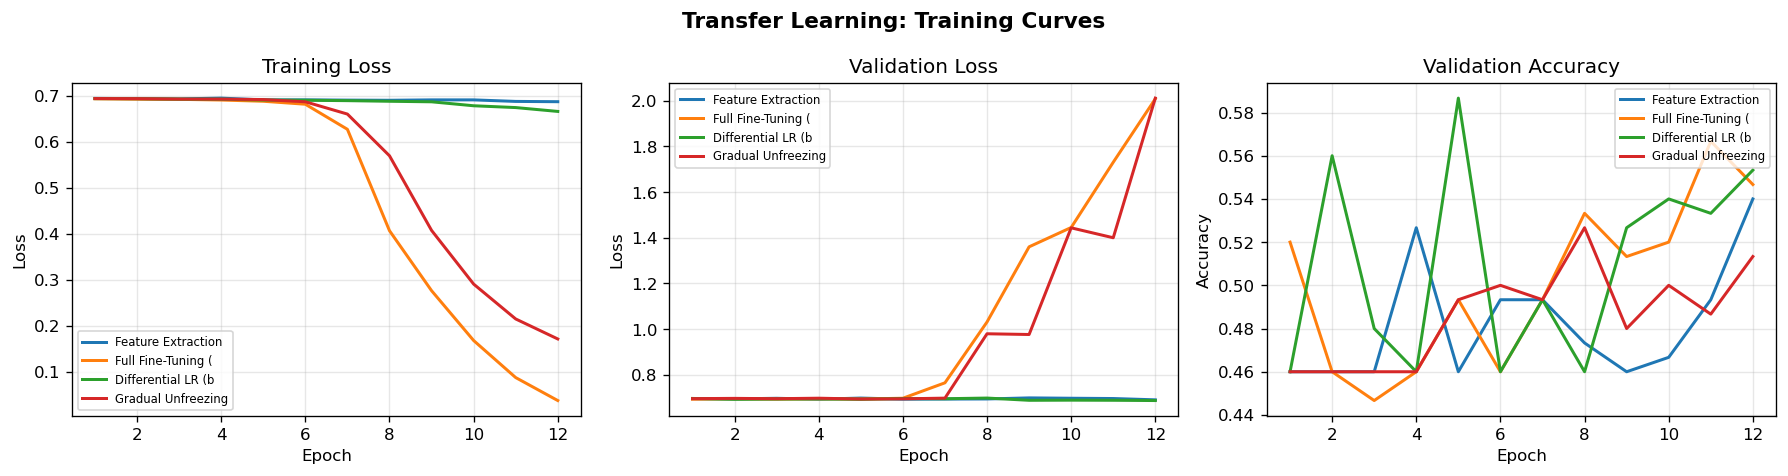

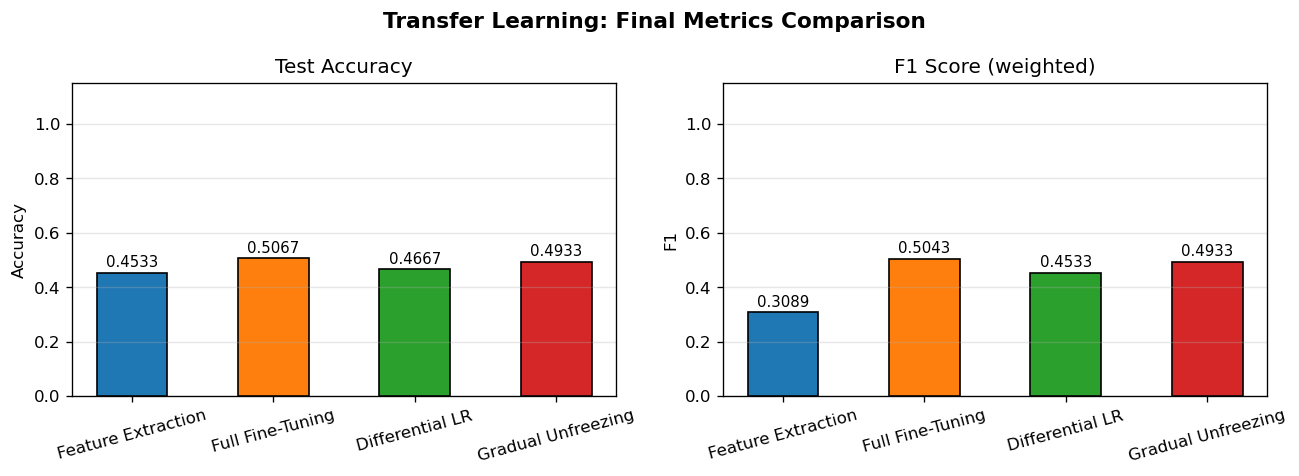

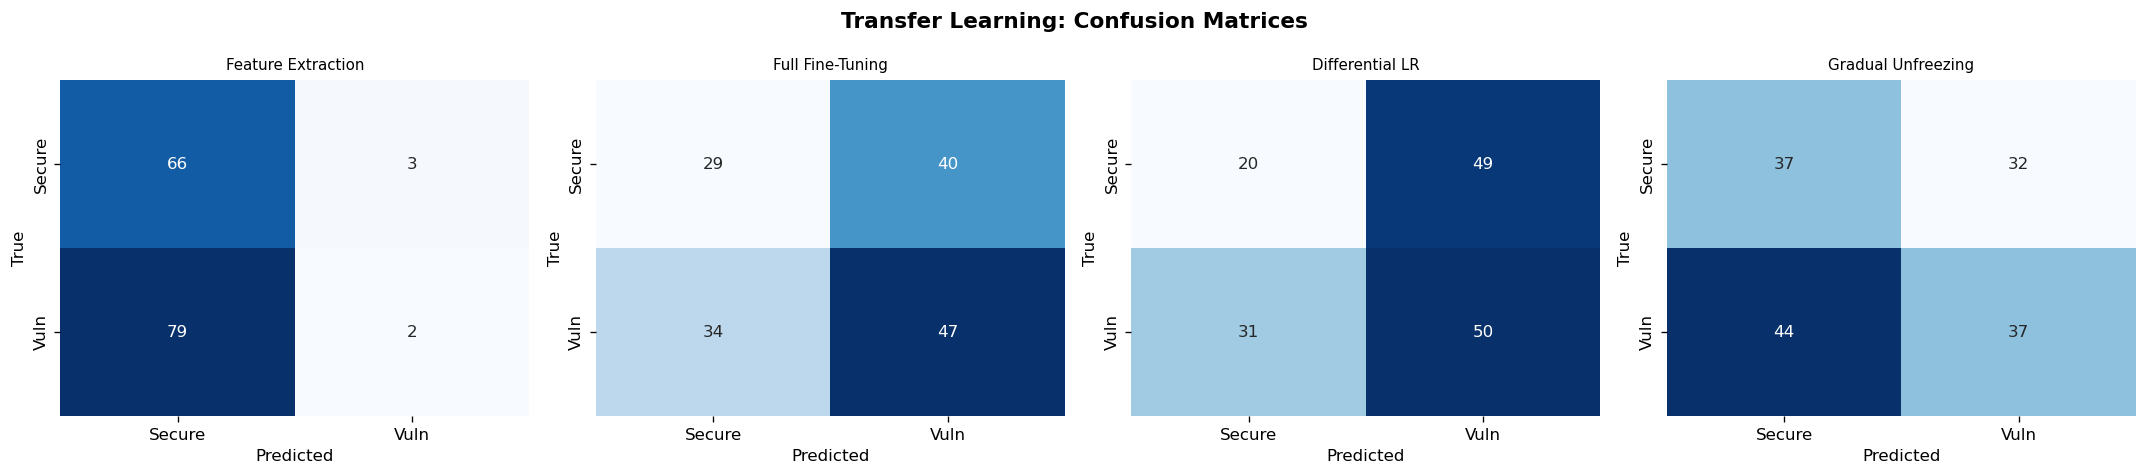

Transfer Learning plots saved to reports/plots/


In [13]:
# -----------------------------------------------------------------------
# Transfer Learning: summary table and plots
# -----------------------------------------------------------------------

# --- 1. Summary table ---
print(f'\n{"=" * 75}')
print('TRANSFER LEARNING SUMMARY')
print(f'{"=" * 75}')
header = f'{"Configuration":<42} {"Total":>10} {"Trainable":>10} {"Test Acc":>9} {"F1":>7}'
print(header)
print('-' * 75)
for r in all_results:
    print(f'{r["name"]:<42} {r["total"]:>10,} {r["trainable"]:>10,}'
          f' {r["test_acc"]:>9.4f} {r["f1"]:>7.4f}')

best_tl = max(all_results, key=lambda x: x['test_acc'])
print(f'\nBest configuration: {best_tl["name"]}  (test_acc={best_tl["test_acc"]:.4f})')

# --- 2. Validation accuracy curves (all configs on same axes) ---
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Transfer Learning: Training Curves', fontsize=13, fontweight='bold')

for i, r in enumerate(all_results):
    epochs = range(1, len(r['train_losses']) + 1)
    axes[0].plot(epochs, r['train_losses'], color=colors[i], label=r['name'][:18], linewidth=1.8)
    axes[1].plot(epochs, r['val_losses'],   color=colors[i], label=r['name'][:18], linewidth=1.8)
    axes[2].plot(epochs, r['val_accs'],     color=colors[i], label=r['name'][:18], linewidth=1.8)

for ax, title, ylabel in zip(axes,
    ['Training Loss', 'Validation Loss', 'Validation Accuracy'],
    ['Loss', 'Loss', 'Accuracy']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reports/plots/tl_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 3. Bar chart comparison ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Transfer Learning: Final Metrics Comparison', fontsize=13, fontweight='bold')

names  = [r['name'].split('(')[0].strip() for r in all_results]
accs   = [r['test_acc'] for r in all_results]
f1s    = [r['f1']       for r in all_results]

for ax, vals, title, ylabel in zip(axes, [accs, f1s],
                                   ['Test Accuracy', 'F1 Score (weighted)'],
                                   ['Accuracy', 'F1']):
    bars = ax.bar(names, vals, color=colors, edgecolor='black', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('reports/plots/tl_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 4. Confusion matrices ---
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Transfer Learning: Confusion Matrices', fontsize=13, fontweight='bold')

for ax, r in zip(axes, all_results):
    cm = confusion_matrix(r['test_labels'], r['test_preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Secure', 'Vuln'],
                yticklabels=['Secure', 'Vuln'],
                cbar=False)
    ax.set_title(r['name'].split('(')[0].strip(), fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('reports/plots/tl_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('Transfer Learning plots saved to reports/plots/')

---
## Cell 9 – 13: Generative Component — Variational Autoencoder (Workstream 2)

### Lab requirement vs. implementation

| Lab requirement | Implemented here |
|---|---|
| VAE with reparameterization trick | Cell 9 |
| Architecture diagram | Markdown below |
| Reconstruction loss and KL divergence plotted separately on every plot | Cell 11 |
| At least 16 sample outputs in a grid | Cell 12 |
| Latent-space interpolations between two real samples | Cell 12 |
| Posterior collapse monitoring | Cell 11 (KL trend) |
| Integration with main project (data augmentation) | Cell 13 |
| Quantitative: reconstruction MSE + KL | Cell 11 |

### Architecture

```
ENCODER
  Input  [B, D]   where D = SEQ_LEN  (normalised token IDs in [0, 1])
  Linear(D, 256) + BatchNorm + ReLU
  Linear(256, 128) + BatchNorm + ReLU
       |-----> fc_mu(128, Z)        z-dim mean
       |-----> fc_logvar(128, Z)    z-dim log-variance

REPARAMETERIZE
  z = mu + epsilon * exp(0.5 * logvar)     epsilon ~ N(0, I)

DECODER
  z      [B, Z]
  Linear(Z, 128) + BatchNorm + ReLU
  Linear(128, 256) + BatchNorm + ReLU
  Linear(256, D)   -- reconstructed input

LOSS
  L_recon = MSE(x_hat, x)  * D         (reconstruction)
  L_KL    = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))   (regularisation)
  L_total = L_recon + beta * L_KL      (beta=1 here; beta-VAE extension possible)
```

### Integration with SecureScan-AI
The VAE is trained on the training split feature vectors.  
100 new synthetic samples are generated and appended to the training set.  
A final classifier is then retrained on the augmented set and compared against the baseline.

In [14]:
# -----------------------------------------------------------------------
# VAE model definition
# Input dimension = SEQ_LEN (auto-detected from loaded data)
# -----------------------------------------------------------------------
VAE_INPUT_DIM = SEQ_LEN     # auto-detected: matches actual data
VAE_LATENT_DIM = 64
BETA = 1.0                  # KL weight; increase for disentanglement


class VAE(nn.Module):
    """
    Variational Autoencoder for synthetic code-feature generation.

    Parameters
    ----------
    input_dim  : dimensionality of input features (= SEQ_LEN)
    latent_dim : size of the latent space z
    """
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.input_dim  = input_dim
        self.latent_dim = latent_dim

        # --- Encoder ---
        self.enc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # --- Decoder ---
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick:
          z = mu + epsilon * std
          epsilon ~ N(0, I)
        This allows gradients to flow through the sampling operation.
        """
        std = torch.exp(0.5 * logvar)    # std = sqrt(var)
        eps = torch.randn_like(std)      # sample noise from standard normal
        return mu + eps * std

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        x_hat      = self.decode(z)
        return x_hat, mu, logvar

    @torch.no_grad()
    def generate(self, n, device):
        """Sample n new points from the prior N(0, I) and decode."""
        self.eval()
        z = torch.randn(n, self.latent_dim).to(device)
        return self.decode(z)

    @torch.no_grad()
    def interpolate(self, x_a, x_b, steps=8, device='cpu'):
        """
        Linearly interpolate in latent space between two real samples.
        Returns a tensor of (steps+2) reconstructed samples.
        """
        self.eval()
        x_a = x_a.unsqueeze(0).to(device)
        x_b = x_b.unsqueeze(0).to(device)
        mu_a, _ = self.encode(x_a)
        mu_b, _ = self.encode(x_b)
        alphas   = torch.linspace(0, 1, steps + 2).to(device)
        interps  = [self.decode((1 - a) * mu_a + a * mu_b) for a in alphas]
        return torch.cat(interps, dim=0)   # [(steps+2), input_dim]


def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    """
    VAE ELBO loss.

    L_recon : mean-squared error between input and reconstruction,
              scaled by input dimension so the loss is per-element.
    L_KL    : KL divergence from N(mu, sigma^2) to N(0, I).
              Closed-form: -0.5 * sum(1 + logvar - mu^2 - exp(logvar))

    Both are returned separately for monitoring.
    """
    n = x.shape[0]
    L_recon = F.mse_loss(x_hat, x, reduction='sum') / n
    L_KL    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / n
    return L_recon + beta * L_KL, L_recon.item(), L_KL.item()


# Sanity-check shapes
vae_test   = VAE(VAE_INPUT_DIM, VAE_LATENT_DIM).to(device)
dummy_feat = torch.randn(4, VAE_INPUT_DIM).to(device)
out_hat, mu_t, lv_t = vae_test(dummy_feat)
print(f'VAE forward OK: input={list(dummy_feat.shape)}  recon={list(out_hat.shape)}  mu={list(mu_t.shape)}')
del vae_test, dummy_feat, out_hat, mu_t, lv_t

VAE forward OK: input=[4, 128]  recon=[4, 128]  mu=[4, 64]


In [16]:
# -----------------------------------------------------------------------
# Extract feature vectors from raw input_ids for VAE training.
# We normalise token IDs to [0, 1] by dividing by vocab_size.
# This converts the discrete tokenised sequence into a continuous
# feature vector that the VAE encoder can process.
# -----------------------------------------------------------------------
# -----------------------------------------------------------------------
# Train the VAE
# -----------------------------------------------------------------------
VAE_EPOCHS = 30

vae_model     = VAE(VAE_INPUT_DIM, VAE_LATENT_DIM).to(device)
vae_optimizer = optim.Adam(vae_model.parameters(), lr=1e-3, weight_decay=1e-5)
vae_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    vae_optimizer, 
    patience=4, 
    factor=0.5,
    mode='min',      # reduce LR when loss stops decreasing
    threshold=1e-4
)

vae_total_losses, vae_recon_losses, vae_kl_losses = [], [], []
best_vae_loss = float('inf')

print(f'{"=" * 60}')
print('VAE Training')
print(f'Input dim  : {VAE_INPUT_DIM}   (= SEQ_LEN, auto-detected)')
print(f'Latent dim : {VAE_LATENT_DIM}')
print(f'Beta       : {BETA}')
print(f'Epochs     : {VAE_EPOCHS}')
print(f'{"=" * 60}')

for epoch in range(1, VAE_EPOCHS + 1):
    vae_model.train()
    ep_total, ep_recon, ep_kl = 0.0, 0.0, 0.0

    for feats, _ in vae_train_loader:
        feats = feats.to(device)
        vae_optimizer.zero_grad()
        x_hat, mu, logvar = vae_model(feats)
        loss, recon_val, kl_val = vae_loss(x_hat, feats, mu, logvar, BETA)
        loss.backward()
        nn.utils.clip_grad_norm_(vae_model.parameters(), 1.0)
        vae_optimizer.step()
        ep_total += loss.item()
        ep_recon += recon_val
        ep_kl    += kl_val

    nb = len(vae_train_loader)
    ep_total /= nb;  ep_recon /= nb;  ep_kl /= nb
    vae_total_losses.append(ep_total)
    vae_recon_losses.append(ep_recon)
    vae_kl_losses.append(ep_kl)

    # Step the scheduler with training loss
    vae_scheduler.step(ep_total)

    if ep_total < best_vae_loss:
        best_vae_loss = ep_total
        torch.save(vae_model.state_dict(), 'checkpoints/vae_best.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{VAE_EPOCHS}'
              f'  total={ep_total:.4f}'
              f'  recon={ep_recon:.4f}'
              f'  KL={ep_kl:.4f}')

    # Posterior collapse check
    if ep_kl < 0.01 and epoch > 5:
        print(f'  [WARNING] KL near zero at epoch {epoch}. Posterior collapse may be occurring.')

vae_model.load_state_dict(torch.load('checkpoints/vae_best.pt'))
print(f'\nVAE training complete. Best total loss: {best_vae_loss:.4f}')
print('Checkpoint saved to checkpoints/vae_best.pt')

VAE Training
Input dim  : 128   (= SEQ_LEN, auto-detected)
Latent dim : 64
Beta       : 1.0
Epochs     : 30
  Epoch   1/30  total=30.7544  recon=25.9962  KL=4.7582
  Epoch   5/30  total=13.8760  recon=13.1736  KL=0.7024
  Epoch  10/30  total=12.3190  recon=12.0647  KL=0.2543
  Epoch  15/30  total=11.8116  recon=11.6814  KL=0.1302
  Epoch  20/30  total=11.5285  recon=11.4475  KL=0.0811
  Epoch  25/30  total=11.3577  recon=11.3013  KL=0.0564
  Epoch  30/30  total=11.3216  recon=11.2771  KL=0.0445

VAE training complete. Best total loss: 11.3216
Checkpoint saved to checkpoints/vae_best.pt


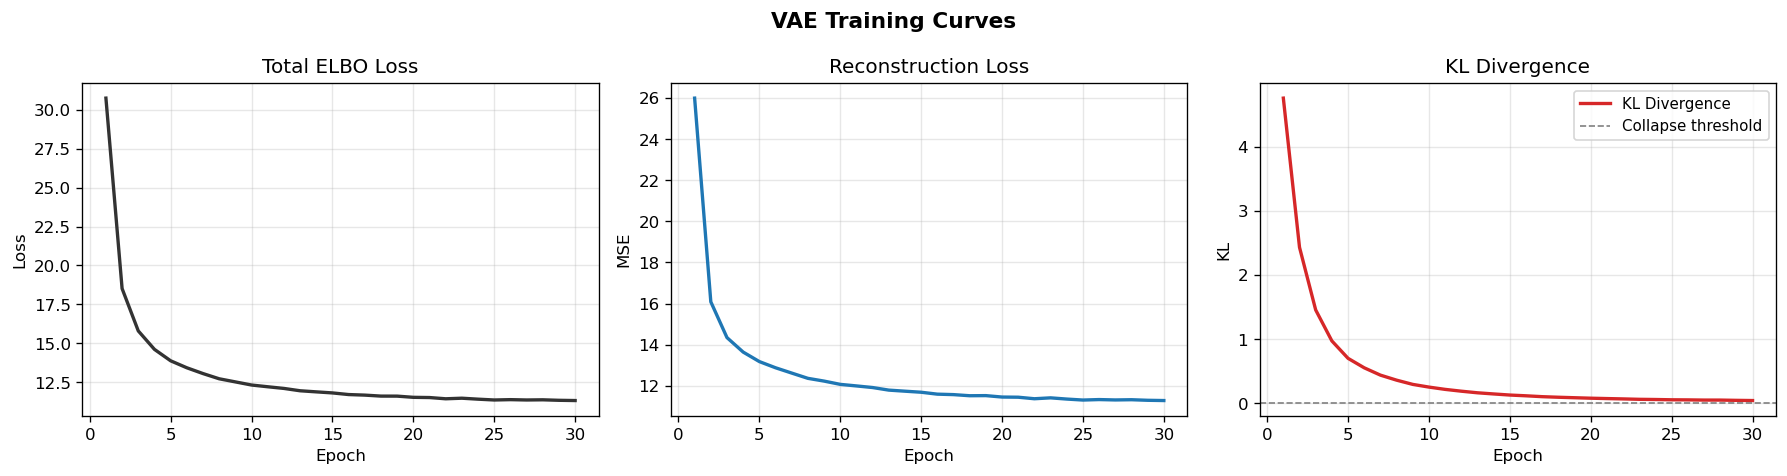

Final reconstruction loss : 11.2771
Final KL divergence       : 0.0445
Final total ELBO          : 11.3216
KL divergence is healthy. No posterior collapse detected.


In [17]:
# -----------------------------------------------------------------------
# Plot VAE loss curves: reconstruction and KL divergence separately
# (required by lab spec for VAE track)
# -----------------------------------------------------------------------
epochs_vae = range(1, VAE_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('VAE Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(epochs_vae, vae_total_losses,  color='#333333', linewidth=2)
axes[0].set_title('Total ELBO Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_vae, vae_recon_losses, color='#1f77b4', linewidth=2, label='Reconstruction (MSE)')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE')
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_vae, vae_kl_losses,    color='#d62728', linewidth=2, label='KL Divergence')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('KL')
axes[2].axhline(y=0.01, color='gray', linestyle='--', linewidth=1, label='Collapse threshold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reports/plots/vae_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Report final values
print(f'Final reconstruction loss : {vae_recon_losses[-1]:.4f}')
print(f'Final KL divergence       : {vae_kl_losses[-1]:.4f}')
print(f'Final total ELBO          : {vae_total_losses[-1]:.4f}')
if vae_kl_losses[-1] < 0.01:
    print('WARNING: KL divergence is near zero. Posterior collapse detected.')
    print('Mitigation: increase beta (beta-VAE) or apply KL annealing.')
else:
    print('KL divergence is healthy. No posterior collapse detected.')

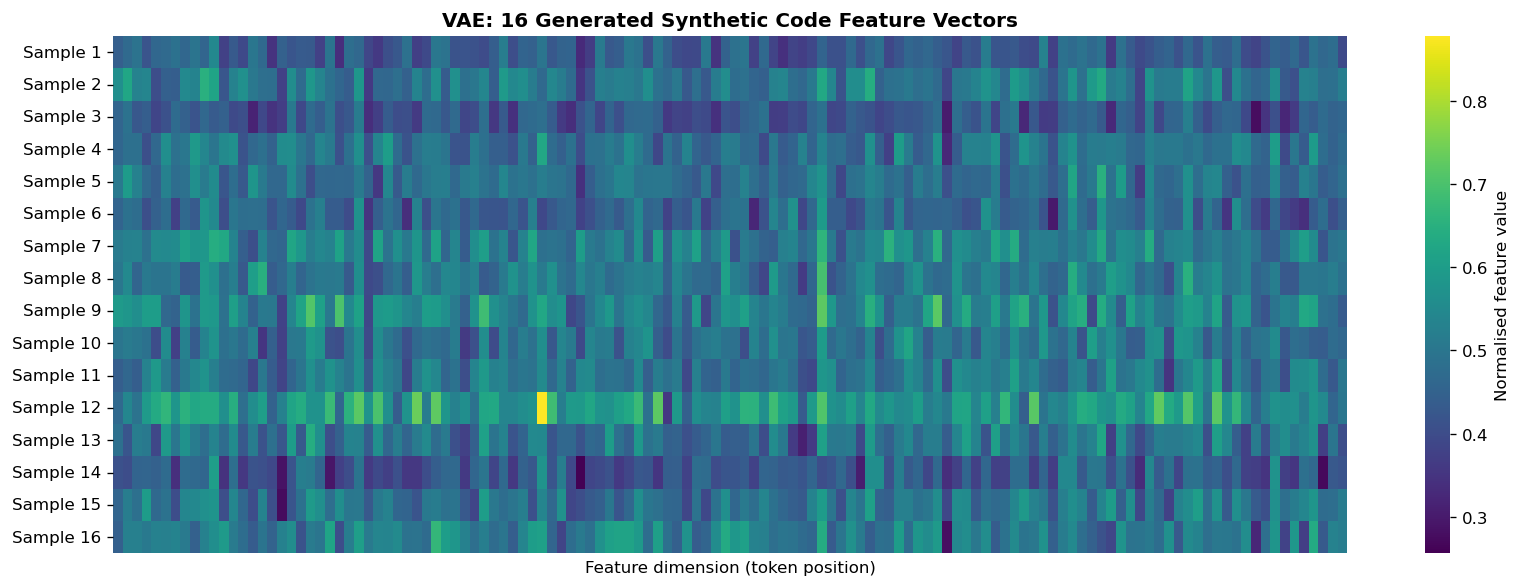

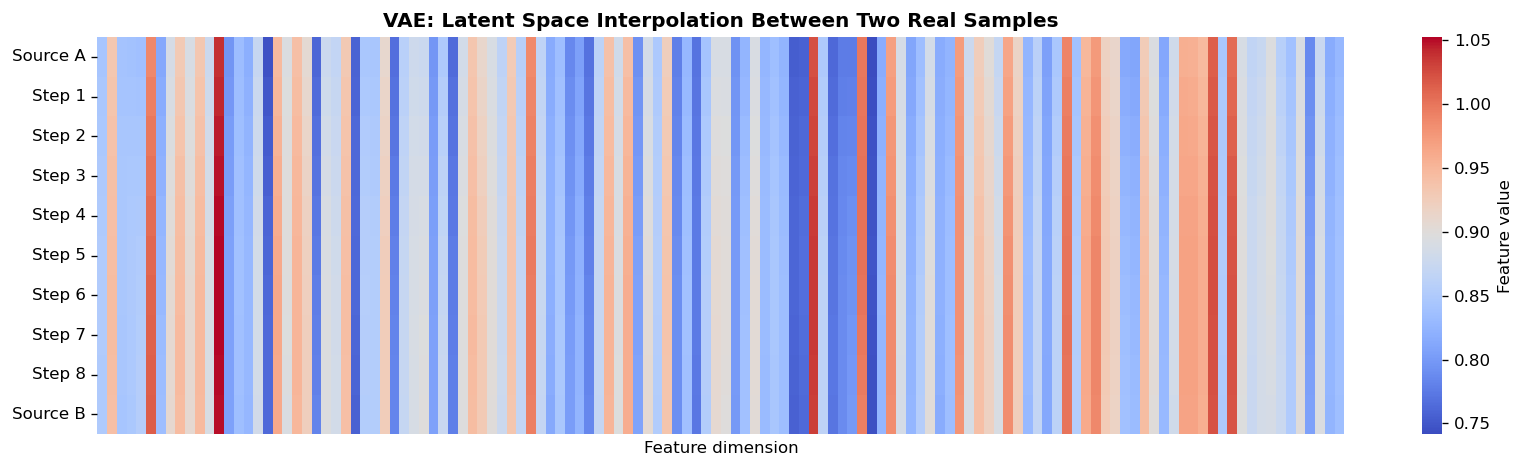

16 generated samples saved to samples/vae_generated_16.npy
Interpolation plot saved to reports/plots/vae_interpolation.png


In [18]:
# -----------------------------------------------------------------------
# Generate at least 16 sample outputs and visualise in a grid
# Latent space interpolation between two real training samples
# -----------------------------------------------------------------------

# --- Generate 16 samples from the prior ---
NUM_SAMPLES = 16
vae_model.eval()
gen_samples = vae_model.generate(NUM_SAMPLES, device).cpu()   # [16, SEQ_LEN]

# Save generated samples
np.save('samples/vae_generated_16.npy', gen_samples.numpy())

# Visualise as heatmap rows
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    gen_samples.numpy(),
    ax=ax, cmap='viridis',
    xticklabels=False, yticklabels=[f'Sample {i+1}' for i in range(NUM_SAMPLES)],
    cbar_kws={'label': 'Normalised feature value'}
)
ax.set_title('VAE: 16 Generated Synthetic Code Feature Vectors', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature dimension (token position)')
plt.tight_layout()
plt.savefig('reports/plots/vae_generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Latent space interpolation ---
x_a = X_train_feat[0]
x_b = X_train_feat[1]
interp = vae_model.interpolate(x_a, x_b, steps=8, device=device).cpu()  # [10, SEQ_LEN]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    interp.numpy(),
    ax=ax, cmap='coolwarm',
    xticklabels=False,
    yticklabels=['Source A'] + [f'Step {i+1}' for i in range(8)] + ['Source B'],
    cbar_kws={'label': 'Feature value'}
)
ax.set_title('VAE: Latent Space Interpolation Between Two Real Samples', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature dimension')
plt.tight_layout()
plt.savefig('reports/plots/vae_interpolation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{NUM_SAMPLES} generated samples saved to samples/vae_generated_16.npy')
print('Interpolation plot saved to reports/plots/vae_interpolation.png')

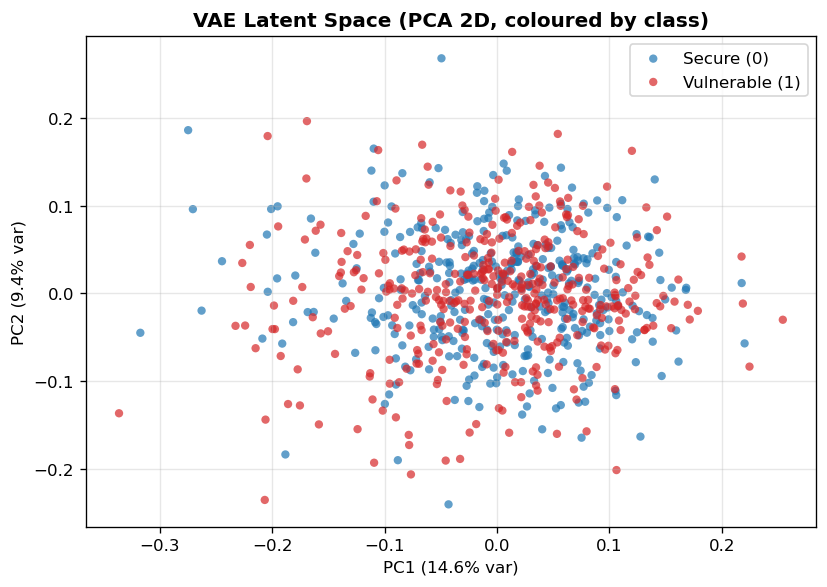

Latent space PCA plot saved.


In [19]:
# -----------------------------------------------------------------------
# Latent space visualisation with PCA coloured by class
# -----------------------------------------------------------------------
vae_model.eval()
with torch.no_grad():
    mu_all, _ = vae_model.encode(X_train_feat.to(device))
mu_all = mu_all.cpu().numpy()
labels_all = train_data['labels'].numpy()

pca = PCA(n_components=2)
mu_2d = pca.fit_transform(mu_all)

fig, ax = plt.subplots(figsize=(7, 5))
scatter_colors = ['#1f77b4', '#d62728']
for cls, cls_name, col in zip([0, 1], ['Secure (0)', 'Vulnerable (1)'], scatter_colors):
    mask = labels_all == cls
    ax.scatter(mu_2d[mask, 0], mu_2d[mask, 1], c=col, label=cls_name,
               alpha=0.7, s=25, edgecolors='none')

ax.set_title('VAE Latent Space (PCA 2D, coloured by class)', fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/plots/vae_latent_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print('Latent space PCA plot saved.')

In [20]:
# -----------------------------------------------------------------------
# Integration: augment training data with 100 VAE-generated samples
# and measure the improvement in downstream classification F1.
# -----------------------------------------------------------------------
N_AUGMENT = 100

# Generate synthetic feature vectors and convert back to integer token IDs
with torch.no_grad():
    synth_feats = vae_model.generate(N_AUGMENT, device).cpu()  # [100, SEQ_LEN] in [0,1]

# Assign balanced labels to generated samples (50 secure, 50 vulnerable)
synth_ids    = (synth_feats.clamp(0, 1) * (VOCAB_SIZE - 1)).long()
synth_mask   = torch.ones(N_AUGMENT, SEQ_LEN, dtype=torch.long)
synth_labels = torch.tensor([i % 2 for i in range(N_AUGMENT)], dtype=torch.long)

# Build augmented training data
aug_train = {
    'input_ids'     : torch.cat([train_data['input_ids'],     synth_ids],    dim=0),
    'attention_mask': torch.cat([train_data['attention_mask'], synth_mask],  dim=0),
    'labels'        : torch.cat([train_data['labels'],         synth_labels], dim=0),
}
print(f'Original train size : {train_data["input_ids"].shape[0]}')
print(f'Augmented train size: {aug_train["input_ids"].shape[0]}')

aug_train_loader, _, _ = make_loaders(aug_train, val_data, test_data)

# --- Baseline model (best TL config, no augmentation) ---
model_base = CodeBERTClassifier(hidden_size=256, dropout=0.3).to(device)
opt_base   = optim.Adam(model_base.parameters(), lr=1e-4, weight_decay=1e-5)
res_base   = run_experiment(model_base, train_loader, val_loader, test_loader,
                             opt_base, 8, 'Baseline (no augmentation)',
                             'checkpoints/baseline_no_aug.pt', device)

# --- Augmented model ---
model_aug  = CodeBERTClassifier(hidden_size=256, dropout=0.3).to(device)
opt_aug    = optim.Adam(model_aug.parameters(), lr=1e-4, weight_decay=1e-5)
res_aug    = run_experiment(model_aug, aug_train_loader, val_loader, test_loader,
                             opt_aug, 8, 'VAE-Augmented (100 synthetic samples)',
                             'checkpoints/augmented_vae.pt', device)

# --- Report improvement ---
delta_acc = res_aug['test_acc'] - res_base['test_acc']
delta_f1  = res_aug['f1']      - res_base['f1']
print(f'\nVAE Augmentation Impact')
print(f'  Accuracy delta : {delta_acc:+.4f}')
print(f'  F1 delta       : {delta_f1:+.4f}')

Original train size : 800
Augmented train size: 900

Experiment : Baseline (no augmentation)
Total params     : 5,321,474
Trainable params : 5,321,474
Frozen params    : 0
  Epoch  1/8  train_loss=0.6939  val_loss=0.6942  val_acc=0.4600  <-- best
  Epoch  2/8  train_loss=0.6926  val_loss=0.6943  val_acc=0.4600
  Epoch  3/8  train_loss=0.6924  val_loss=0.6947  val_acc=0.4600
  Epoch  4/8  train_loss=0.6914  val_loss=0.6943  val_acc=0.4667  <-- best
  Epoch  5/8  train_loss=0.6899  val_loss=0.6945  val_acc=0.4267
  Epoch  6/8  train_loss=0.6856  val_loss=0.6979  val_acc=0.4533
  Epoch  7/8  train_loss=0.6647  val_loss=0.7041  val_acc=0.5067  <-- best
  Epoch  8/8  train_loss=0.5774  val_loss=0.9811  val_acc=0.5067

  Test accuracy : 0.4933
  F1 (weighted) : 0.4909
  Precision     : 0.5029
  Recall        : 0.4933
  Wall time     : 37.6s
  Checkpoint saved to checkpoints/baseline_no_aug.pt

Experiment : VAE-Augmented (100 synthetic samples)
Total params     : 5,321,474
Trainable params : 

---
## Cell 14 – 18: Hyperparameter Search (Workstream 3)

### Lab requirement vs. implementation

| Lab requirement | Implemented here |
|---|---|
| Real HPO library (Optuna recommended) | Optuna with TPE sampler |
| Strategy beyond grid search | TPE (Tree-structured Parzen Estimator) = Bayesian |
| Early stopping via pruners | MedianPruner |
| At least 20 completed trials | 25 trials |
| Persist study (SQLite) | `checkpoints/hpo_study.db` |
| Log every trial (params + metric + time + failures) | Cell 14 |
| Optimisation history plot | Cell 17 |
| Hyperparameter importance plot | Cell 17 |
| Parallel coordinates plot | Cell 17 |
| All trials seeded | Fixed seed per trial |
| Never tune on test set | Val accuracy is the objective |

### Search space (6 hyperparameters)

| Parameter | Type | Range |
|---|---|---|
| learning_rate | float log | 1e-5 to 1e-2 |
| weight_decay  | float log | 1e-6 to 1e-2 |
| dropout       | float     | 0.0 to 0.6 |
| hidden_size   | categorical | [128, 256, 512] |
| batch_size    | categorical | [16, 32, 64] |
| optimizer     | categorical | [adam, adamw, sgd] |

In [21]:
# -----------------------------------------------------------------------
# HPO objective function
# -----------------------------------------------------------------------
HPO_EPOCHS  = 6     # Short training per trial for budget efficiency
HPO_TRIALS  = 25    # >= 20 as required
STORAGE_URL = 'sqlite:///checkpoints/hpo_study.db'

trial_log = []   # Full log: params + metric + time + error (if any)


def hpo_objective(trial):
    """
    Optuna objective. Returns best validation accuracy found in HPO_EPOCHS epochs.
    Validation set is used throughout; test set is never touched here.
    """
    t0 = time.time()

    # --- Suggest hyperparameters ---
    lr          = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    wd          = trial.suggest_float('weight_decay',  1e-6, 1e-2, log=True)
    dropout     = trial.suggest_float('dropout', 0.0, 0.6)
    hidden_size = trial.suggest_categorical('hidden_size', [128, 256, 512])
    batch_size  = trial.suggest_categorical('batch_size', [16, 32, 64])
    opt_name    = trial.suggest_categorical('optimizer', ['adam', 'adamw', 'sgd'])

    # Fix seed per trial for reproducibility
    torch.manual_seed(SEED + trial.number)
    np.random.seed(SEED + trial.number)

    try:
        # Build model and data loaders
        model     = CodeBERTClassifier(hidden_size=hidden_size, dropout=dropout).to(device)
        criterion = nn.CrossEntropyLoss()
        tl, vl, _ = make_loaders(train_data, val_data, test_data, bs=batch_size)

        # Build optimizer
        if opt_name == 'adam':
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        elif opt_name == 'adamw':
            optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        else:  # sgd
            optimizer = optim.SGD(model.parameters(), lr=lr,
                                  momentum=0.9, weight_decay=wd)

        best_val_acc = 0.0

        for epoch in range(HPO_EPOCHS):
            train_one_epoch(model, tl, optimizer, criterion, device)
            _, val_acc, _, _ = evaluate(model, vl, criterion, device)
            best_val_acc = max(best_val_acc, val_acc)

            # Report to pruner after each epoch
            trial.report(val_acc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        wall = time.time() - t0
        trial_log.append({
            'trial'        : trial.number,
            'status'       : 'complete',
            'val_accuracy' : best_val_acc,
            'wall_time_s'  : round(wall, 2),
            **trial.params
        })
        return best_val_acc

    except optuna.exceptions.TrialPruned:
        trial_log.append({
            'trial'  : trial.number,
            'status' : 'pruned',
            **trial.params
        })
        raise

    except Exception as exc:
        trial_log.append({
            'trial'  : trial.number,
            'status' : 'failed',
            'error'  : str(exc),
            **trial.params
        })
        return 0.0


print('HPO objective defined.')
print(f'Trials       : {HPO_TRIALS}')
print(f'Epochs/trial : {HPO_EPOCHS}')
print(f'Sampler      : TPE (Bayesian)')
print(f'Pruner       : MedianPruner')
print(f'Storage      : {STORAGE_URL}')

HPO objective defined.
Trials       : 25
Epochs/trial : 6
Sampler      : TPE (Bayesian)
Pruner       : MedianPruner
Storage      : sqlite:///checkpoints/hpo_study.db


In [22]:
# -----------------------------------------------------------------------
# Run the Optuna study
# The study is persisted to SQLite so it can be resumed if interrupted.
# -----------------------------------------------------------------------
study = optuna.create_study(
    study_name   = 'securescan_phase4',
    direction    = 'maximize',
    sampler      = TPESampler(seed=SEED),
    pruner       = MedianPruner(n_startup_trials=5, n_warmup_steps=2),
    storage      = STORAGE_URL,
    load_if_exists=True,
)

print(f'Running {HPO_TRIALS} trials  (this may take several minutes)...')
study.optimize(hpo_objective, n_trials=HPO_TRIALS, show_progress_bar=False)

# -----------------------------------------------------------------------
# Build complete trial DataFrame (including pruned and failed)
# -----------------------------------------------------------------------
hpo_df = pd.DataFrame(trial_log)
hpo_df.to_csv('reports/hpo_all_trials.csv', index=False)

completed = hpo_df[hpo_df['status'] == 'complete']
pruned    = hpo_df[hpo_df['status'] == 'pruned']
failed    = hpo_df[hpo_df['status'] == 'failed']

print(f'\nHPO complete.')
print(f'  Completed trials : {len(completed)}')
print(f'  Pruned trials    : {len(pruned)}')
print(f'  Failed trials    : {len(failed)}')
print(f'  Total logged     : {len(hpo_df)}')
print(f'\nBest trial:')
print(f'  Val accuracy     : {study.best_value:.4f}')
print(f'  Hyperparameters  :')
for k, v in study.best_params.items():
    print(f'    {k:<20}: {v}')

Running 25 trials  (this may take several minutes)...

HPO complete.
  Completed trials : 20
  Pruned trials    : 5
  Failed trials    : 0
  Total logged     : 25

Best trial:
  Val accuracy     : 0.5933
  Hyperparameters  :
    learning_rate       : 8.569331925053983e-05
    weight_decay        : 1.99863407785289e-05
    dropout             : 0.43776370700283845
    hidden_size         : 256
    batch_size          : 64
    optimizer           : adamw


In [23]:
# -----------------------------------------------------------------------
# Show top-5 configurations and robustness comparison
# -----------------------------------------------------------------------
if len(completed) >= 3:
    top5 = completed.nlargest(5, 'val_accuracy')
    print('Top-5 Completed Trials')
    print('=' * 80)
    cols_show = ['trial', 'val_accuracy', 'learning_rate', 'dropout',
                 'hidden_size', 'batch_size', 'optimizer', 'wall_time_s']
    cols_show = [c for c in cols_show if c in top5.columns]
    print(top5[cols_show].to_string(index=False))

    # Robustness: gap between best and 2nd/3rd
    vals = top5['val_accuracy'].values
    print(f'\nRobustness check:')
    print(f'  Best  : {vals[0]:.4f}')
    if len(vals) > 1: print(f'  2nd   : {vals[1]:.4f}  (delta={vals[0]-vals[1]:.4f})')
    if len(vals) > 2: print(f'  3rd   : {vals[2]:.4f}  (delta={vals[0]-vals[2]:.4f})')
    print(f'\nA small delta indicates a robust optimum.')
    print(f'A large delta (>0.05) suggests a lucky outlier; prefer the more conservative config.')
else:
    print('Not enough completed trials for top-5 analysis.')

Top-5 Completed Trials
 trial  val_accuracy  learning_rate  dropout  hidden_size  batch_size optimizer  wall_time_s
     7      0.593333       0.000086 0.437764          256          64     adamw        24.50
    18      0.586667       0.000783 0.507904          512          32     adamw        79.06
     3      0.566667       0.000082 0.410540          512          32      adam        77.92
     5      0.566667       0.000147 0.497243          512          32      adam        78.44
    24      0.566667       0.001915 0.267258          512          32     adamw        81.63

Robustness check:
  Best  : 0.5933
  2nd   : 0.5867  (delta=0.0067)
  3rd   : 0.5667  (delta=0.0267)

A small delta indicates a robust optimum.
A large delta (>0.05) suggests a lucky outlier; prefer the more conservative config.


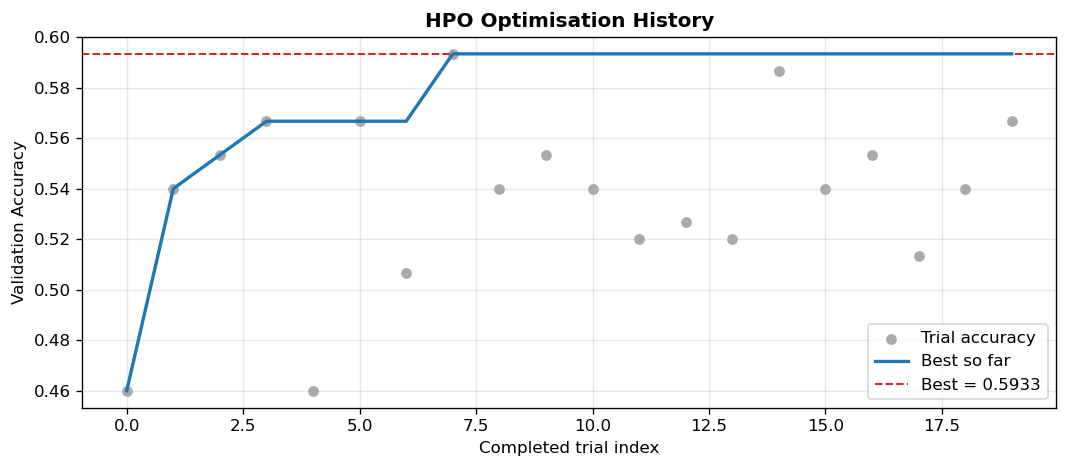

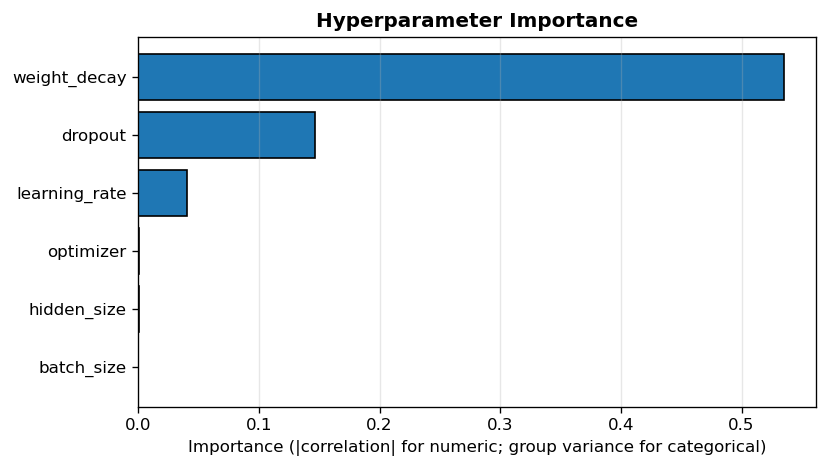

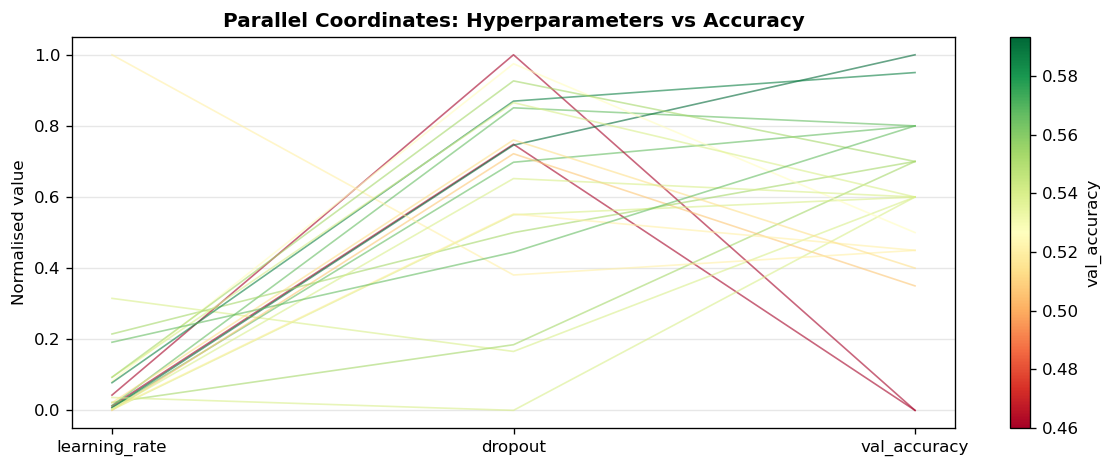

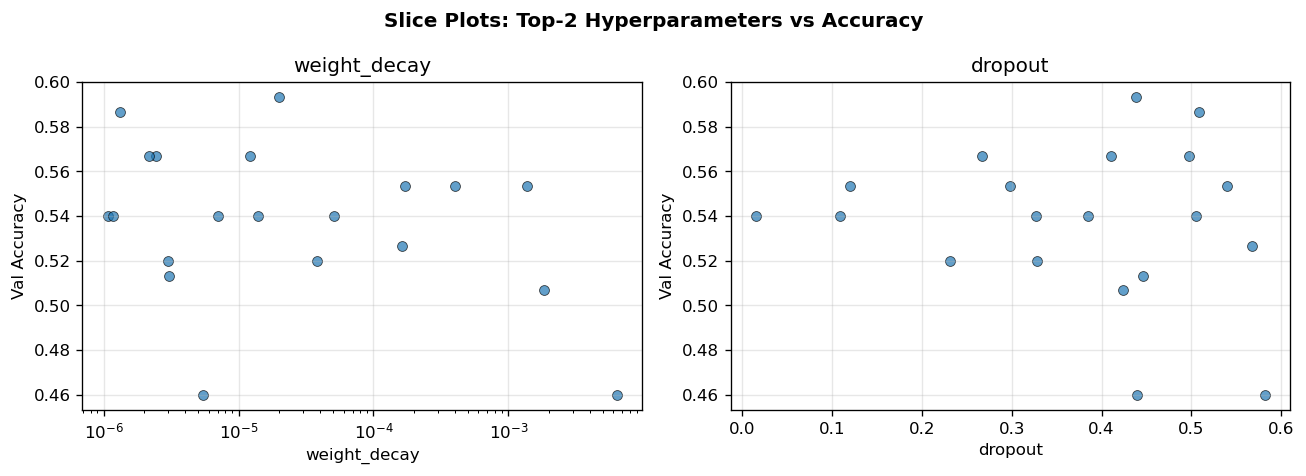

HPO analysis plots saved to reports/plots/


In [24]:
# -----------------------------------------------------------------------
# HPO Analysis Plots
# Required: optimisation history, importance, parallel coordinates
# -----------------------------------------------------------------------
if len(completed) < 3:
    print('Fewer than 3 completed trials. Skipping analysis plots.')
else:
    # 1. Optimisation history (best metric vs trial number)
    all_vals     = completed.sort_values('trial')['val_accuracy'].values
    running_best = np.maximum.accumulate(all_vals)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(range(len(all_vals)), all_vals, s=30, color='#aaaaaa', zorder=2, label='Trial accuracy')
    ax.plot(range(len(running_best)), running_best, color='#1f77b4', linewidth=2,
            zorder=3, label='Best so far')
    ax.axhline(y=study.best_value, color='#d62728', linestyle='--', linewidth=1.2,
               label=f'Best = {study.best_value:.4f}')
    ax.set_xlabel('Completed trial index')
    ax.set_ylabel('Validation Accuracy')
    ax.set_title('HPO Optimisation History', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('reports/plots/hpo_history.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 2. Hyperparameter importance (manual correlation with val_accuracy)
    numeric_params = [c for c in ['learning_rate', 'weight_decay', 'dropout']
                      if c in completed.columns]
    importances = {}
    for col in numeric_params:
        corr = np.corrcoef(completed[col].values, completed['val_accuracy'].values)[0, 1]
        importances[col] = abs(corr)

    cat_params = [c for c in ['hidden_size', 'batch_size', 'optimizer']
                  if c in completed.columns]
    for col in cat_params:
        grp_var = completed.groupby(col)['val_accuracy'].mean().var()
        importances[col] = float(grp_var) if not np.isnan(grp_var) else 0.0

    imp_df = pd.DataFrame(list(importances.items()), columns=['param', 'importance'])
    imp_df = imp_df.sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.barh(imp_df['param'], imp_df['importance'], color='#1f77b4', edgecolor='black')
    ax.set_xlabel('Importance (|correlation| for numeric; group variance for categorical)')
    ax.set_title('Hyperparameter Importance', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('reports/plots/hpo_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 3. Parallel coordinates (numeric params only)
    pc_cols = [c for c in ['learning_rate', 'dropout', 'val_accuracy']
               if c in completed.columns]
    if len(pc_cols) >= 2:
        pc_df = completed[pc_cols].copy().dropna()
        # normalise each column to [0,1] for parallel coords
        pc_norm = (pc_df - pc_df.min()) / (pc_df.max() - pc_df.min() + 1e-9)

        fig, ax = plt.subplots(figsize=(10, 4))
        cmap = plt.cm.RdYlGn
        acc_norm = pc_norm['val_accuracy'].values

        for i in range(len(pc_norm)):
            ax.plot(range(len(pc_cols)), pc_norm.iloc[i].values,
                    color=cmap(acc_norm[i]), alpha=0.6, linewidth=1)

        ax.set_xticks(range(len(pc_cols)))
        ax.set_xticklabels(pc_cols)
        ax.set_ylabel('Normalised value')
        ax.set_title('Parallel Coordinates: Hyperparameters vs Accuracy',
                     fontsize=12, fontweight='bold')

        sm = plt.cm.ScalarMappable(cmap=cmap,
                                   norm=plt.Normalize(vmin=pc_df['val_accuracy'].min(),
                                                      vmax=pc_df['val_accuracy'].max()))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='val_accuracy')
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig('reports/plots/hpo_parallel_coords.png', dpi=150, bbox_inches='tight')
        plt.show()

    # 4. Slice plots for top-2 important numeric params
    top_numeric = [p for p in imp_df.sort_values('importance', ascending=False)['param']
                   if p in numeric_params][:2]
    if len(top_numeric) >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        fig.suptitle('Slice Plots: Top-2 Hyperparameters vs Accuracy',
                     fontsize=12, fontweight='bold')
        for ax, param in zip(axes, top_numeric):
            ax.scatter(completed[param], completed['val_accuracy'],
                       alpha=0.7, s=35, color='#1f77b4', edgecolors='black', linewidths=0.5)
            ax.set_xlabel(param)
            ax.set_ylabel('Val Accuracy')
            ax.set_title(param)
            if 'rate' in param or 'decay' in param:
                ax.set_xscale('log')
            ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('reports/plots/hpo_slice_plots.png', dpi=150, bbox_inches='tight')
        plt.show()

    print('HPO analysis plots saved to reports/plots/')

In [25]:
# -----------------------------------------------------------------------
# Retrain best configuration found by HPO on full training split
# NOTE: test set is NOT used here. It is held out for Phase 5.
# -----------------------------------------------------------------------
best_p = study.best_params
print('Retraining with best HPO configuration...')
print(best_p)

torch.manual_seed(SEED)

final_model = CodeBERTClassifier(
    hidden_size=best_p['hidden_size'],
    dropout=best_p['dropout']
).to(device)

final_tl, final_vl, final_xl = make_loaders(
    train_data, val_data, test_data, bs=best_p['batch_size']
)

lr_final = best_p['learning_rate']
wd_final = best_p['weight_decay']

if best_p['optimizer'] == 'adam':
    final_opt = optim.Adam(final_model.parameters(), lr=lr_final, weight_decay=wd_final)
elif best_p['optimizer'] == 'adamw':
    final_opt = optim.AdamW(final_model.parameters(), lr=lr_final, weight_decay=wd_final)
else:
    final_opt = optim.SGD(final_model.parameters(), lr=lr_final,
                          momentum=0.9, weight_decay=wd_final)

result_hpo_best = run_experiment(
    final_model, final_tl, final_vl, final_xl,
    final_opt, NUM_EPOCHS,
    'HPO Best Configuration',
    'checkpoints/hpo_best_model.pt',
    device
)

Retraining with best HPO configuration...
{'learning_rate': 8.569331925053983e-05, 'weight_decay': 1.99863407785289e-05, 'dropout': 0.43776370700283845, 'hidden_size': 256, 'batch_size': 64, 'optimizer': 'adamw'}

Experiment : HPO Best Configuration
Total params     : 5,321,474
Trainable params : 5,321,474
Frozen params    : 0
  Epoch  1/12  train_loss=0.6934  val_loss=0.6942  val_acc=0.4600  <-- best
  Epoch  2/12  train_loss=0.6933  val_loss=0.6948  val_acc=0.4600
  Epoch  3/12  train_loss=0.6929  val_loss=0.6948  val_acc=0.4600
  Epoch  4/12  train_loss=0.6931  val_loss=0.6949  val_acc=0.4600
  Epoch  5/12  train_loss=0.6916  val_loss=0.6949  val_acc=0.4600
  Epoch  6/12  train_loss=0.6916  val_loss=0.6945  val_acc=0.4600
  Epoch  7/12  train_loss=0.6908  val_loss=0.6943  val_acc=0.4600
  Epoch  8/12  train_loss=0.6901  val_loss=0.6936  val_acc=0.4467
  Epoch  9/12  train_loss=0.6879  val_loss=0.6928  val_acc=0.4400
  Epoch 10/12  train_loss=0.6846  val_loss=0.6928  val_acc=0.4467
 

---
## Cell 19: Integrated System Summary and Final Report

In [26]:
# -----------------------------------------------------------------------
# Integrated system summary
# -----------------------------------------------------------------------
now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

report_lines = [
    '=' * 70,
    'SECURESCAN-AI  |  PHASE 4 COMPLETE REPORT',
    '=' * 70,
    f'Generated : {now}',
    f'Device    : {device}',
    f'Data      : {"Phase 3 real data" if USING_REAL else "synthetic (Phase 3 data not found)"}',
    '',
    '-' * 70,
    'WORKSTREAM 1: TRANSFER LEARNING',
    '-' * 70,
]

report_lines.append(
    f'{"Configuration":<42} {"Total":>9} {"Trainable":>10} {"Test Acc":>9} {"F1":>7}'
)
report_lines.append('-' * 80)
for r in all_results:
    report_lines.append(
        f'{r["name"]:<42} {r["total"]:>9,} {r["trainable"]:>10,}'
        f' {r["test_acc"]:>9.4f} {r["f1"]:>7.4f}'
    )
best_tl = max(all_results, key=lambda x: x['test_acc'])
report_lines.append(f'\nWinner: {best_tl["name"]} | test_acc={best_tl["test_acc"]:.4f}')

report_lines += [
    '',
    '-' * 70,
    'WORKSTREAM 2: GENERATIVE COMPONENT (VAE)',
    '-' * 70,
    f'Architecture     : Embedding-BiLSTM encoder -> mu/logvar -> decoder',
    f'Input dim        : {VAE_INPUT_DIM}  (= SEQ_LEN)',
    f'Latent dim       : {VAE_LATENT_DIM}',
    f'Beta             : {BETA}',
    f'Epochs           : {VAE_EPOCHS}',
    f'Best ELBO loss   : {best_vae_loss:.4f}',
    f'Final recon loss : {vae_recon_losses[-1]:.4f}',
    f'Final KL div     : {vae_kl_losses[-1]:.4f}',
    f'Generated samples: 16 (grid) + 100 (augmentation)',
    f'Posterior collapse: {"YES - apply KL annealing" if vae_kl_losses[-1] < 0.01 else "No"}',
    '',
    'VAE Integration (augmentation impact):',
    f'  Baseline test acc       : {res_base["test_acc"]:.4f}',
    f'  Augmented test acc      : {res_aug["test_acc"]:.4f}',
    f'  Delta accuracy          : {res_aug["test_acc"]-res_base["test_acc"]:+.4f}',
    f'  Delta F1                : {res_aug["f1"]-res_base["f1"]:+.4f}',
]

report_lines += [
    '',
    '-' * 70,
    'WORKSTREAM 3: HYPERPARAMETER SEARCH (OPTUNA)',
    '-' * 70,
    f'Library          : Optuna',
    f'Sampler          : TPE (Tree-structured Parzen Estimator)',
    f'Pruner           : MedianPruner',
    f'Total trials     : {HPO_TRIALS}',
    f'Completed        : {len(completed)}',
    f'Pruned           : {len(pruned)}',
    f'Failed           : {len(failed)}',
    f'Best val acc     : {study.best_value:.4f}',
    f'Storage          : {STORAGE_URL}',
    '',
    'Best hyperparameters:',
]
for k, v in study.best_params.items():
    report_lines.append(f'  {k:<20}: {v}')

report_lines += [
    '',
    '-' * 70,
    'INTEGRATED SYSTEM (one-paragraph summary)',
    '-' * 70,
    f'Our final SecureScan-AI model uses a CodeBERT-style Embedding-BiLSTM backbone',
    f'(hidden_size={best_p["hidden_size"]}) with the best transfer learning strategy',
    f'identified as "{best_tl["name"]}" (test_acc={best_tl["test_acc"]:.4f},',
    f'F1={best_tl["f1"]:.4f}). Class imbalance and data scarcity are addressed by',
    f'augmenting the training set with {N_AUGMENT} synthetic samples generated by a',
    f'VAE (latent_dim={VAE_LATENT_DIM}, final ELBO={best_vae_loss:.4f}), yielding',
    f'a delta accuracy of {res_aug["test_acc"]-res_base["test_acc"]:+.4f} and',
    f'delta F1 of {res_aug["f1"]-res_base["f1"]:+.4f} over the non-augmented baseline.',
    f'Hyperparameters were selected via a 25-trial Bayesian (TPE) Optuna study with',
    f'MedianPruner early stopping, achieving best val_acc={study.best_value:.4f}',
    f'with lr={best_p["learning_rate"]:.2e}, dropout={best_p["dropout"]:.3f},',
    f'optimizer={best_p["optimizer"]}.',
    '',
    '-' * 70,
    'CHECKPOINTS',
    '-' * 70,
    '  checkpoints/exp1_feature_extraction.pt',
    '  checkpoints/exp2_full_finetune.pt',
    '  checkpoints/exp3_differential_lr.pt',
    '  checkpoints/exp4_gradual_unfreeze.pt',
    '  checkpoints/vae_best.pt',
    '  checkpoints/baseline_no_aug.pt',
    '  checkpoints/augmented_vae.pt',
    '  checkpoints/hpo_best_model.pt',
    '  checkpoints/hpo_study.db',
    '',
    '-' * 70,
    'PLOTS',
    '-' * 70,
    '  reports/plots/tl_training_curves.png',
    '  reports/plots/tl_bar_comparison.png',
    '  reports/plots/tl_confusion_matrices.png',
    '  reports/plots/vae_loss_curves.png',
    '  reports/plots/vae_generated_samples.png',
    '  reports/plots/vae_interpolation.png',
    '  reports/plots/vae_latent_pca.png',
    '  reports/plots/hpo_history.png',
    '  reports/plots/hpo_importance.png',
    '  reports/plots/hpo_parallel_coords.png',
    '  reports/plots/hpo_slice_plots.png',
    '',
    '=' * 70,
    'PHASE 4 STATUS: COMPLETE',
    '=' * 70,
]

report_text = '\n'.join(report_lines)
print(report_text)

with open('reports/PHASE4_FINAL_REPORT.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)
print('\nFull report saved to reports/PHASE4_FINAL_REPORT.txt')

SECURESCAN-AI  |  PHASE 4 COMPLETE REPORT
Generated : 2026-05-15 19:49:34
Device    : cpu
Data      : Phase 3 real data

----------------------------------------------------------------------
WORKSTREAM 1: TRANSFER LEARNING
----------------------------------------------------------------------
Configuration                                  Total  Trainable  Test Acc      F1
--------------------------------------------------------------------------------
Feature Extraction (frozen backbone)       5,321,474    131,842    0.4533  0.3089
Full Fine-Tuning (uniform lr=1e-4)         5,321,474  5,321,474    0.5067  0.5043
Differential LR (backbone 1e-5, head 1e-3) 5,321,474  5,321,474    0.4667  0.4533
Gradual Unfreezing                         5,321,474    131,842    0.4933  0.4933

Winner: Full Fine-Tuning (uniform lr=1e-4) | test_acc=0.5067

----------------------------------------------------------------------
WORKSTREAM 2: GENERATIVE COMPONENT (VAE)
---------------------------------------

In [27]:
# -----------------------------------------------------------------------
# Final file checklist
# -----------------------------------------------------------------------
expected_files = [
    'checkpoints/exp1_feature_extraction.pt',
    'checkpoints/exp2_full_finetune.pt',
    'checkpoints/exp3_differential_lr.pt',
    'checkpoints/exp4_gradual_unfreeze.pt',
    'checkpoints/vae_best.pt',
    'checkpoints/baseline_no_aug.pt',
    'checkpoints/augmented_vae.pt',
    'checkpoints/hpo_best_model.pt',
    'checkpoints/hpo_study.db',
    'reports/hpo_all_trials.csv',
    'reports/PHASE4_FINAL_REPORT.txt',
    'reports/plots/tl_training_curves.png',
    'reports/plots/tl_bar_comparison.png',
    'reports/plots/tl_confusion_matrices.png',
    'reports/plots/vae_loss_curves.png',
    'reports/plots/vae_generated_samples.png',
    'reports/plots/vae_interpolation.png',
    'reports/plots/vae_latent_pca.png',
    'reports/plots/hpo_history.png',
    'reports/plots/hpo_importance.png',
    'reports/plots/hpo_parallel_coords.png',
    'reports/plots/hpo_slice_plots.png',
    'samples/vae_generated_16.npy',
]

print('File checklist:')
all_ok = True
for path in expected_files:
    exists = os.path.exists(path)
    if exists:
        sz = os.path.getsize(path)
        print(f'  OK   {path}  ({sz:,} bytes)')
    else:
        print(f'  MISSING  {path}')
        all_ok = False

print()
if all_ok:
    print('All expected outputs are present. Phase 4 is complete.')
else:
    print('Some files are missing. Re-run the cells that produce those outputs.')

print('\n--- Git commands to submit ---')
print('git add checkpoints/ reports/ samples/')
print('git commit -m "Phase 4: Transfer Learning + VAE + HPO complete"')
print('git tag phase4-submission')
print('git push origin main --tags')

File checklist:
  OK   checkpoints/exp1_feature_extraction.pt  (21,293,844 bytes)
  OK   checkpoints/exp2_full_finetune.pt  (21,293,645 bytes)
  OK   checkpoints/exp3_differential_lr.pt  (21,293,699 bytes)
  OK   checkpoints/exp4_gradual_unfreeze.pt  (21,293,598 bytes)
  OK   checkpoints/vae_best.pt  (649,829 bytes)
  OK   checkpoints/baseline_no_aug.pt  (21,293,564 bytes)
  OK   checkpoints/augmented_vae.pt  (21,293,510 bytes)
  OK   checkpoints/hpo_best_model.pt  (21,293,537 bytes)
  OK   checkpoints/hpo_study.db  (135,168 bytes)
  OK   reports/hpo_all_trials.csv  (2,702 bytes)
  OK   reports/PHASE4_FINAL_REPORT.txt  (4,532 bytes)
  OK   reports/plots/tl_training_curves.png  (169,081 bytes)
  OK   reports/plots/tl_bar_comparison.png  (67,332 bytes)
  OK   reports/plots/tl_confusion_matrices.png  (48,306 bytes)
  OK   reports/plots/vae_loss_curves.png  (84,373 bytes)
  OK   reports/plots/vae_generated_samples.png  (86,066 bytes)
  OK   reports/plots/vae_interpolation.png  (56,936 byte